In [4]:
## Phase 0: Environment Setup

In [5]:
# Phase 0 - Library Imports

import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from wordcloud import WordCloud

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
## Phase 1: Clinical Preprocessing

In [11]:
df = pd.read_csv("mtsamples.csv")
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [12]:
# Keep only required columns
df = df[['medical_specialty', 'transcription']].dropna()
print("Columns after cleaning:")
print(df.columns)
print("\nTotal rows after removing NaNs:", len(df))
df.head()

Columns after cleaning:
Index(['medical_specialty', 'transcription'], dtype='object')

Total rows after removing NaNs: 4966


,medical_specialty,transcription
0,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...


In [13]:
# Check distribution of specialties
df['medical_specialty'].value_counts().head(10)

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64

In [14]:
# Select top 4 specialties
top_specialties = df['medical_specialty'].value_counts().head(4).index

df = df[df['medical_specialty'].isin(top_specialties)]

print("Filtered dataset size:", len(df))
df['medical_specialty'].value_counts()

Filtered dataset size: 2330


medical_specialty
Surgery                       1088
Consult - History and Phy.     516
Cardiovascular / Pulmonary     371
Orthopedic                     355
Name: count, dtype: int64

In [15]:
# Remove common clinical headers

def clean_headers(text):
    text = re.sub(r"SUBJECTIVE:.*?(?=OBJECTIVE:|$)", "", text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r"OBJECTIVE:.*?(?=ASSESSMENT:|$)", "", text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r"\n+", " ", text)
    return text.strip()

df['clean_text'] = df['transcription'].apply(clean_headers)

df[['transcription', 'clean_text']].head(1)

,transcription,clean_text
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."


In [16]:
# Expand common medical abbreviations

abbrev_dict = {
    "pt": "patient",
    "hx": "history",
    "dx": "diagnosis",
    "sx": "symptoms",
    "tx": "treatment",
    "c/o": "complains of",
    "h/o": "history of"
}

def expand_abbreviations(text):
    for short, full in abbrev_dict.items():
        text = re.sub(rf"\b{short}\b", full, text, flags=re.IGNORECASE)
    return text

df['clean_text'] = df['clean_text'].apply(expand_abbreviations)

df['clean_text'].head(3)

3    2-D M-MODE: , ,1.  Left atrial enlargement wit...
4    1.  The left ventricular cavity size and wall ...
7    2-D ECHOCARDIOGRAM,Multiple views of the heart...
Name: clean_text, dtype: object

In [18]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded.")

spaCy model loaded.


In [21]:
import spacy
# Load spaCy but disable heavy components
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
processed_texts = []
for doc in nlp.pipe(df['clean_text'], batch_size=100):
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    processed_texts.append(" ".join(tokens))
df['processed_text'] = processed_texts
df[['clean_text', 'processed_text']].head(2)

,clean_text,processed_text
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",2 d M MODE 1 leave atrial enlargement leave at...
4,1. The left ventricular cavity size and wall ...,1 left ventricular cavity size wall thickness ...


In [22]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [23]:
df[['clean_text', 'processed_text']].head(1)

,clean_text,processed_text
3,"2-D M-MODE: , ,1. Left atrial enlargement with left atrial diameter of 4.7 cm.,2. Normal size right and left ventricle.,3. Normal LV systolic function with left ventricular ejection fraction of 51%.,4. Normal LV diastolic function.,5. No pericardial effusion.,6. Normal morphology of aortic valve, mitral valve, tricuspid valve, and pulmonary valve.,7. PA systolic pressure is 36 mmHg.,DOPPLER: , ,1. Mild mitral and tricuspid regurgitation.,2. Trace aortic and pulmonary regurgitation.","2 d M MODE 1 leave atrial enlargement leave atrial diameter 4.7 cm ,2 normal size right left ventricle ,3 normal LV systolic function leave ventricular ejection fraction 51%.,4 Normal LV diastolic function ,5 pericardial effusion ,6 normal morphology aortic valve mitral valve tricuspid valve pulmonary valve ,7 PA systolic pressure 36 mmHg ,DOPPLER 1 mild mitral tricuspid regurgitation ,2 trace aortic pulmonary regurgitation"


In [24]:
## Phase 2: Entity Extraction using POS Tagging

In [25]:
# Extract nouns and adjectives

def extract_entities(text):
    doc = nlp(text)
    nouns = [token.text for token in doc if token.pos_ == "NOUN"]
    adjectives = [token.text for token in doc if token.pos_ == "ADJ"]
    return nouns, adjectives
df['entities'] = df['clean_text'].apply(extract_entities)
df['entities'].head(3)

3                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           ([enlargement, diameter, cm, size, ventricle, systolic, function, ejection, fraction, diastolic, function, effusion, morphology, valve, valve, tricuspid, valve, valve, pressure, mmHg, mitral, regurgitation, regurgitation], [D, atrial, a

In [31]:
nouns, adjectives = df['entities'].iloc[0]

print("Nouns:", nouns)
print("Adjectives:", adjectives)

Nouns: ['enlargement', 'diameter', 'cm', 'size', 'ventricle', 'systolic', 'function', 'ejection', 'fraction', 'diastolic', 'function', 'effusion', 'morphology', 'valve', 'valve', 'tricuspid', 'valve', 'valve', 'pressure', 'mmHg', 'mitral', 'regurgitation', 'regurgitation']
Adjectives: ['D', 'atrial', 'atrial', 'Normal', 'left', 'Normal', 'ventricular', 'pericardial', 'Normal', 'aortic', 'mitral', 'pulmonary', 'systolic', 'Mild', 'tricuspid', 'aortic', 'pulmonary']


In [34]:
df['medical_specialty'].unique()

array([' Cardiovascular / Pulmonary', ' Surgery', ' Orthopedic',
       ' Consult - History and Phy.'], dtype=object)

In [35]:
cardio_text = " ".join(
    df[df['medical_specialty'].str.contains("Cardio", case=False)]['processed_text']
)
ortho_text = " ".join(
    df[df['medical_specialty'].str.contains("Ortho", case=False)]['processed_text']
)
print(len(cardio_text), len(ortho_text))

742596 850072


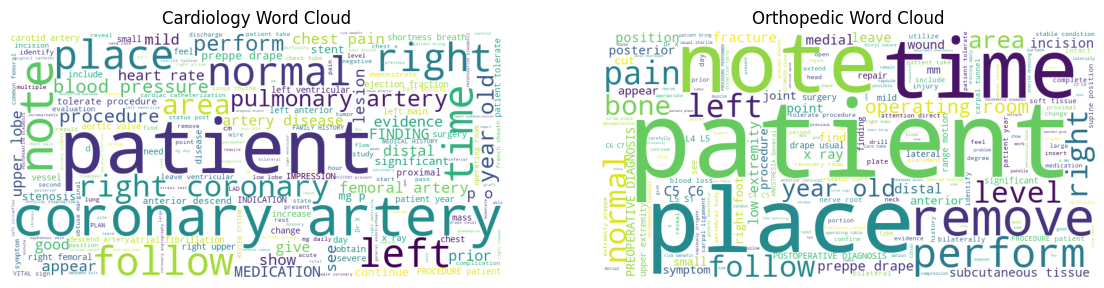

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
cardio_wc = WordCloud(width=800, height=400, background_color='white').generate(cardio_text)
ortho_wc = WordCloud(width=800, height=400, background_color='white').generate(ortho_text)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(cardio_wc)
plt.title("Cardiology Word Cloud")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(ortho_wc)
plt.title("Orthopedic Word Cloud")
plt.axis("off")
plt.show()

In [37]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
# Custom stopwords
medical_stopwords = set(STOPWORDS)
medical_stopwords.update([
    "patient","left","right","year","old","procedure","perform",
    "normal","follow","noted","room","area","level","time",
    "operation","surgery","history","examination","study"
])

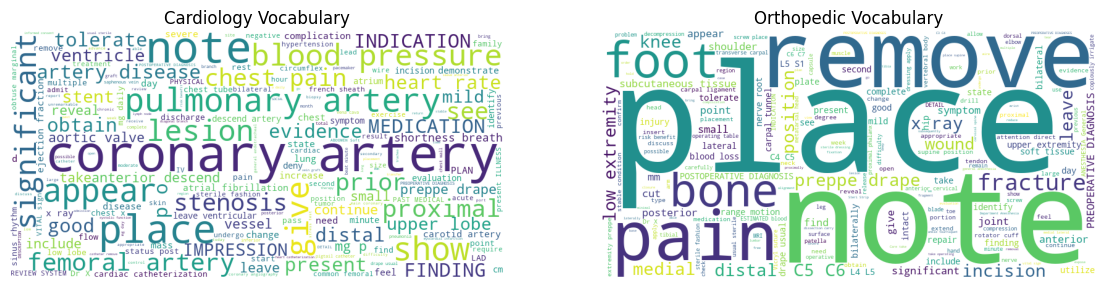

In [38]:
# Generate word clouds with custom stopwords
cardio_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=medical_stopwords
).generate(cardio_text)
ortho_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=medical_stopwords
).generate(ortho_text)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(cardio_wc)
plt.title("Cardiology Vocabulary")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(ortho_wc)
plt.title("Orthopedic Vocabulary")
plt.axis("off")
plt.show()

In [40]:
### The word clouds highlight vocabulary differences between specialties. Cardiology reports emphasize cardiovascular terms such as coronary, artery, pulmonary, and ventricle, while orthopedic reports focus on musculoskeletal terminology including bone, fracture, joint, and tissue. This demonstrates how clinical language varies across departments.

In [42]:
### Phase 3: Syntax & Negation Analysis

In [45]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("spaCy parser enabled.")

spaCy parser enabled.


In [46]:
from spacy import displacy
doc = nlp("Patient denies chest pain")
displacy.render(doc, style="dep", jupyter=True)

In [47]:
### for negation detection:

In [48]:
negation_words = ["no", "not", "denies", "without", "never"]
def detect_negation(sentence, entity):
    doc = nlp(sentence)
    for token in doc:
        if token.text.lower() == entity.lower():
            for ancestor in token.ancestors:
                if ancestor.text.lower() in negation_words:
                    return {"Entity": entity, "Status": "Negated"}
            return {"Entity": entity, "Status": "Present"}

In [53]:
### Testing for negated test

In [50]:
detect_negation("Patient denies chest pain", "pain")

{'Entity': 'pain', 'Status': 'Negated'}

In [51]:
### Not negated test:

In [52]:
detect_negation("Patient has severe chest pain", "pain")

{'Entity': 'pain', 'Status': 'Present'}

In [54]:
### Phase 4: Specialty Classification

In [56]:
### Preparing the data

In [55]:
# Features (text) and labels (specialty)
X = df['processed_text']
y = df['medical_specialty']
print("Number of samples:", len(X))

Number of samples: 2330


In [57]:
### Train/Test split

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1864
Testing samples: 466


In [59]:
### Convert test to numbers (TF-IDF)

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Vectorized training shape:", X_train_vec.shape)

Vectorized training shape: (1864, 5000)


In [61]:
### Training the model

In [62]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)
print("Model training complete.")

Model training complete.


In [63]:
### Making predictions:

In [64]:
y_pred = model.predict(X_test_vec)
print("Predictions generated.")

Predictions generated.


In [65]:
### Evaluating the model:

In [67]:
### Improving accuracy since it was only ~64% earlier

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [82]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [83]:
y_pred = model.predict(X_test_vec)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6952789699570815
                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.51      0.77      0.61        66
 Consult - History and Phy.       0.81      0.68      0.74        97
                 Orthopedic       0.50      0.74      0.59        78
                    Surgery       0.89      0.66      0.76       225

                   accuracy                           0.70       466
                  macro avg       0.68      0.71      0.68       466
               weighted avg       0.75      0.70      0.71       466



In [84]:
### accuracy is now ~70%

In [85]:
### Confusion matrix

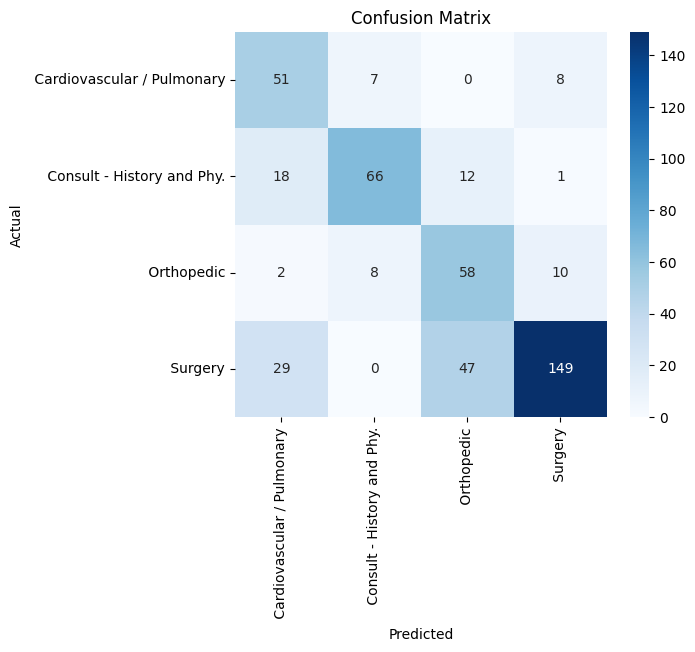

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [87]:
### prediction demo cell

In [88]:
def predict_specialty(text):
    text = preprocess(text)
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)
    return prediction[0]

In [89]:
predict_specialty("Patient with coronary artery blockage and chest pain")

' Cardiovascular / Pulmonary'